In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("dark_background")
df = yf.download(
    "AVGO",
    start="2020-01-01",
    end="2025-02-01",
    auto_adjust=False
)


[*********************100%***********************]  1 of 1 completed


In [2]:
df = df.sort_values("Date")

df = df.reset_index(drop=True) 
df.head()
#dataframe showing the first 5 rows of the dataset56

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AVGO,AVGO,AVGO,AVGO,AVGO,AVGO
0,27.735550,32.238998,32.250000,31.732000,31.931999,20329000
1,27.030100,31.419001,32.000000,31.408001,31.750999,22870000
2,26.989662,31.372000,31.392000,30.962999,31.084999,20789000
3,26.896749,31.264000,31.658001,31.225000,31.525000,18565000
4,26.561228,30.874001,31.349001,30.841000,31.298000,31979000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AVGO)  1278 non-null   float64
 1   (Close, AVGO)      1278 non-null   float64
 2   (High, AVGO)       1278 non-null   float64
 3   (Low, AVGO)        1278 non-null   float64
 4   (Open, AVGO)       1278 non-null   float64
 5   (Volume, AVGO)     1278 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 60.0 KB


In [4]:
df.index

RangeIndex(start=0, stop=1278, step=1)

<Axes: >

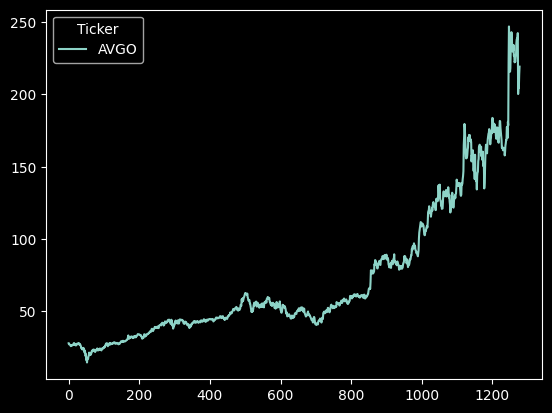

In [5]:
prices = df["Adj Close"]
prices.plot()

In [6]:
prices.iloc[-1]

Ticker
AVGO    219.288422
Name: 1277, dtype: float64

In [7]:
prices.head()



Ticker,AVGO
0,27.735550
1,27.030100
2,26.989662
3,26.896749
4,26.561228


In [8]:
prices.isna().sum()

Ticker
AVGO    0
dtype: int64

In [9]:
prices.describe()

Ticker,AVGO
count,1278.000000
mean,72.448105
std,49.041982
min,14.442033
25%,41.990075
50%,52.653971
75%,86.962046
max,247.099091


In [10]:
prices / prices.shift(1)
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()
log_returns.describe()

Ticker,AVGO
count,1277.000000
mean,0.001619
std,0.026715
min,-0.222056
25%,-0.011621
50%,0.001307
75%,0.014159
max,0.218594


Compare downside vs upside spread:
Downside (Median → Q1):   /50% → 25%
0.13 − (−1.16) ≈ 1.29%
Upside (Q3 → Median):     /75%→50%
1.42 − 0.13 ≈ 1.29%
Symmetrical → returns are fairly balanced
25% quartile (Q1) = −1.16%
50% quartile (Median) = +0.13%
75% quartile (Q3) = +1.42%
below x% of daily log returns was =
above 100-x% was above =
eg. 25% of all daily returns are worse than −1.16%
    75% are better than −1.16%

In [11]:
log_returns.isna().sum()
#counts how many missing values exist in the entire series

Ticker
AVGO    0
dtype: int64

<Axes: >

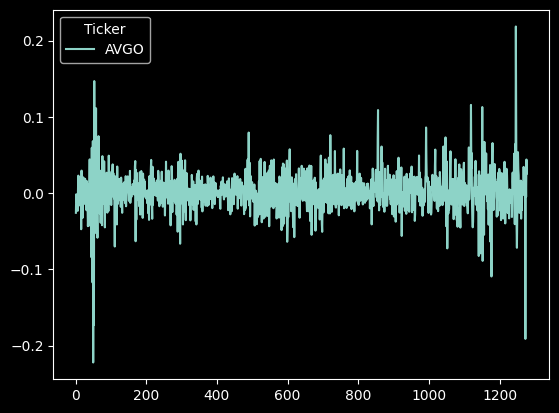

In [12]:
log_returns.plot()


array([[<Axes: title={'center': 'AVGO'}>]], dtype=object)

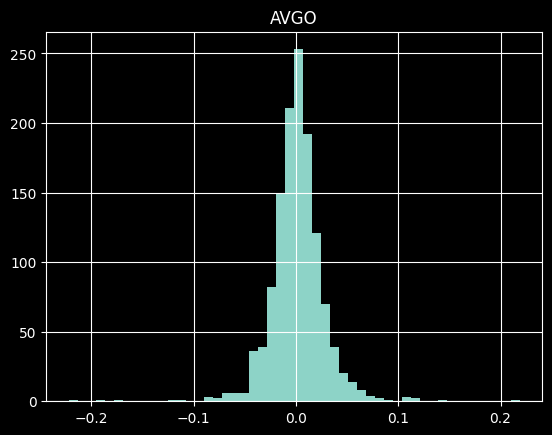

In [13]:
log_returns.hist(bins=50)

In [14]:
mu_hat = log_returns.mean()

In [15]:
sigma_hat = log_returns.std()


sigma(std):
Typical daily fluctuation size
Width of the return distribution

In [16]:
mu_annual = mu_hat * 252


In [17]:
sigma_annual = sigma_hat * np.sqrt(252)

Var  = σ^2
VarT ​= T⋅σ^2
σT   ​= sqrt(T⋅σ^2)
σT   ​=σ.sqrt(T)

Why this works

Returns add linearly over time rmeanx252
→ Mean scales with time 
Variances add, not standard deviations 
→ Std scales with √time

This relies on:
Independence (or weak dependence)
Identically distributed returns

In [18]:

print(mu_hat, sigma_hat)

Ticker
AVGO    0.001619
dtype: float64 Ticker
AVGO    0.026715
dtype: float64


In [19]:
n_days = 252
n_paths = 10000

What could happen over the next year?”
10000 number of alternate futures

In [20]:
sim_returns = np.random.normal(
    mu_hat,
    sigma_hat,
    size=(n_paths, n_days)
)


Path 1: r₁, r₂, r₃, ... r₂₅₂
Path 2: r₁, r₂, r₃, ... r₂₅₂
...
Path 10000

Each row → one possible future
Each column → one day forward in time
Each cell → one simulated daily return

Law of Large Numbers
Monte Carlo works because repeated sampling converges to the true distribution implied by the model

In [21]:
cum_returns = np.cumsum(sim_returns, axis=1)

Each row is daily log returns

But prices depend on accumulated returns
axis=1 → sum horizontally

In [22]:
S0 = prices.iloc[-1].values[0]
type(S0)
#Starting point for all futures simulations

numpy.float64

Take the most recent price in the dataset and store it as the starting price (S₀) for the simulation.
iloc = integer location index
-1 → last element
-2 → second last

In [23]:
sim_prices = S0 * np.exp(cum_returns)
#Log returns sum → cumulative log return
#Exponent converts log-space → price-space

In [24]:
sim_prices[:5, :5]

array([[222.07404126, 217.12551563, 211.83474886, 210.2642347 ,
        219.44921994],
       [213.52069208, 217.80624749, 218.77493236, 221.63895064,
        227.71815477],
       [218.87218371, 226.00289686, 220.30964313, 215.16784793,
        227.16413436],
       [220.04218149, 214.00498529, 209.09486875, 205.75772664,
        199.8599811 ],
       [223.13588183, 224.56697415, 221.27116592, 221.53040856,
        229.13970765]])

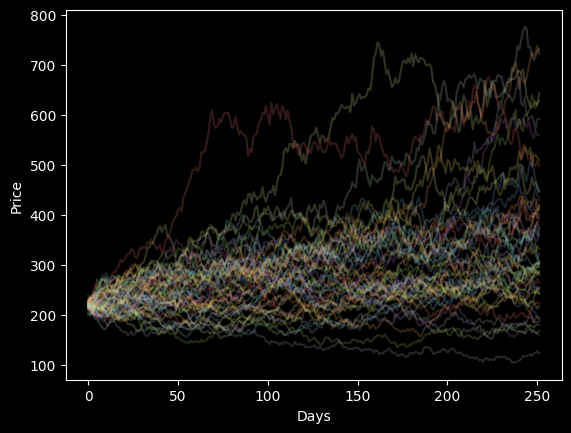

In [25]:
plt.plot(sim_prices[:50].T, alpha=0.2)
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

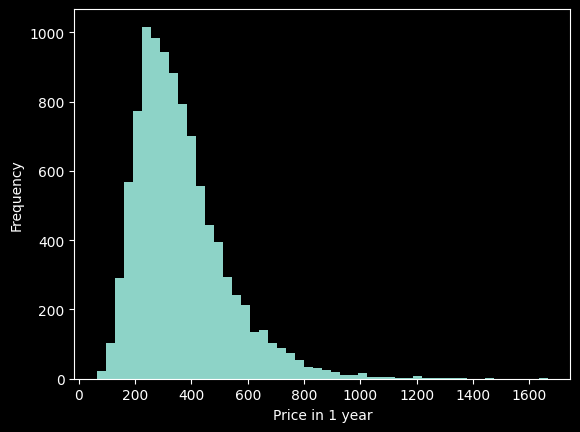

In [26]:
final_prices = sim_prices[:, -1]
plt.hist(final_prices, bins=50)
plt.xlabel("Price in 1 year")
plt.ylabel("Frequency")
plt.show()
#right skewed distribution 

In [27]:
final_prices.mean()

np.float64(363.5417444044426)

In [28]:
VaR_5 = np.percentile(final_prices, 5)
VaR_5
#95% of simulated outcomes end above this price , 5% end below
#95% confidence, the price will not fall below VaR5 in one year
#left tail 

np.float64(167.04237409802354)

In [29]:
VaR_loss = S0 - VaR_5
VaR_loss
#In the worst 5% of cases, the loss exceeds this amount

np.float64(52.24604753283583)

In [30]:
ES_5 = final_prices[final_prices <= VaR_5].mean()
ES_5
#how bad the tail is
#EXPECTED SHORTFALL (ES) or Conditional Value at Risk (CVaR)
#5% ES =“Average outcome given that we are in the worst 5%.”

np.float64(141.26022669365437)

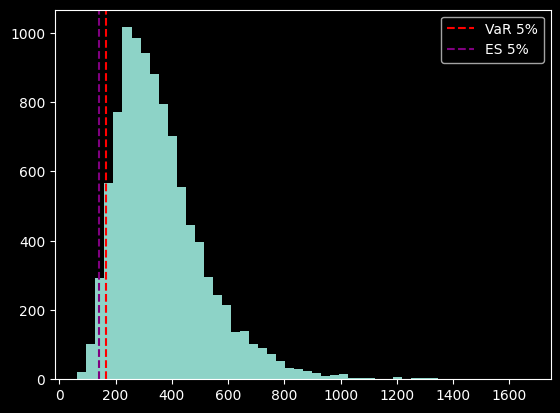

In [31]:
plt.hist(final_prices, bins=50)
plt.axvline(VaR_5, color="red", linestyle="--", label="VaR 5%")
plt.axvline(ES_5, color="purple", linestyle="--", label="ES 5%")
plt.legend()
plt.show()